In [ ]:
!pip install astropy

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
DATA_PATH = "/content/drive/MyDrive/continuum_data_subset"

Mounted at /content/drive


In [ ]:
import numpy as np
import glob
from astropy.io import fits
import matplotlib.pyplot as plt
from skimage.transform import resize
from sklearn.decomposition import PCA
import hdbscan
import umap
from scipy.ndimage import gaussian_filter1d
from scipy.signal import find_peaks

/usr/local/lib/python3.12/dist-packages/hdbscan/robust_single_linkage_.py:175: SyntaxWarning: invalid escape sequence '\{'
  $max \{ core_k(a), core_k(b), 1/\alpha d(a,b) \}$.


In [ ]:
def load_fits_files(folder):
  files = glob.glob(folder + '/*.fits')
  images=[]
  c=0
  for f in files:
    with fits.open(f) as hdul:
      data = hdul[0].data
      img = data[0,0].squeeze()
      images.append(img)
      c+=1
      print(c)
  return np.array(images), files

In [ ]:
images, filenames = load_fits_files(DATA_PATH)
print("Loaded", len(images))

1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
Loaded 150


In [ ]:
print(images[0].shape)

(600, 600)


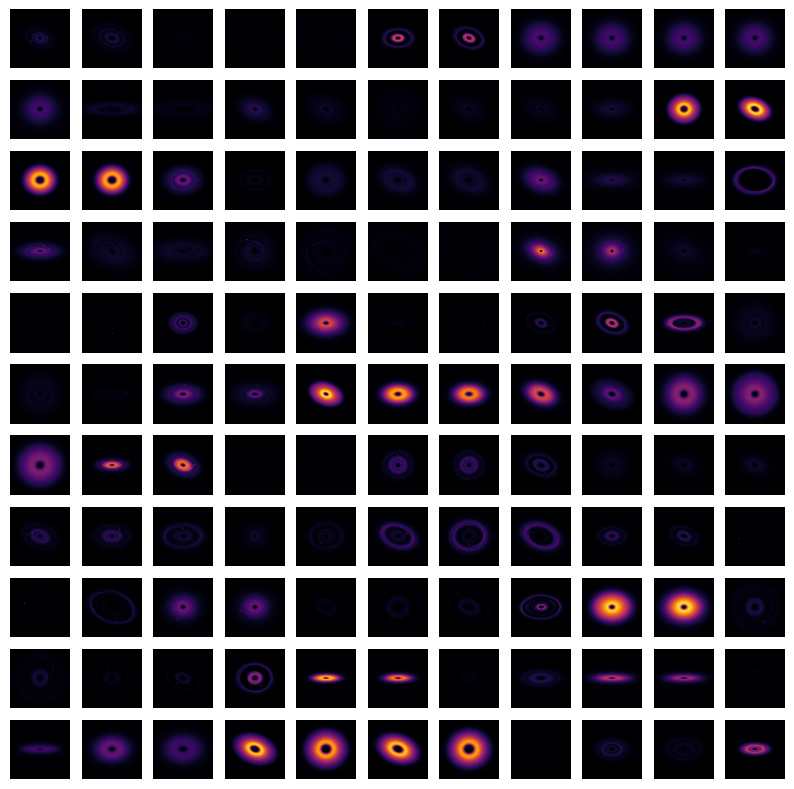

In [ ]:
plt.figure(figsize=(10,10))
for i in range(121):
  plt.subplot(11,11,i+1)
  plt.imshow(images[i], cmap='inferno')
  plt.axis('off')
plt.show()

In [ ]:
def preprocess(image):
  norm_img = image/np.max(image) #dividing by max brightness to normalize
  log_img = np.log1p(norm_img) #logarithmic transformation so faint rings are visible
  resize_img = np.array(resize(log_img, (128,128))) #resizing to 128x128
  return resize_img

In [ ]:
processed_images = np.array([preprocess(img) for img in images])
print(processed_images.shape)

(150, 128, 128)


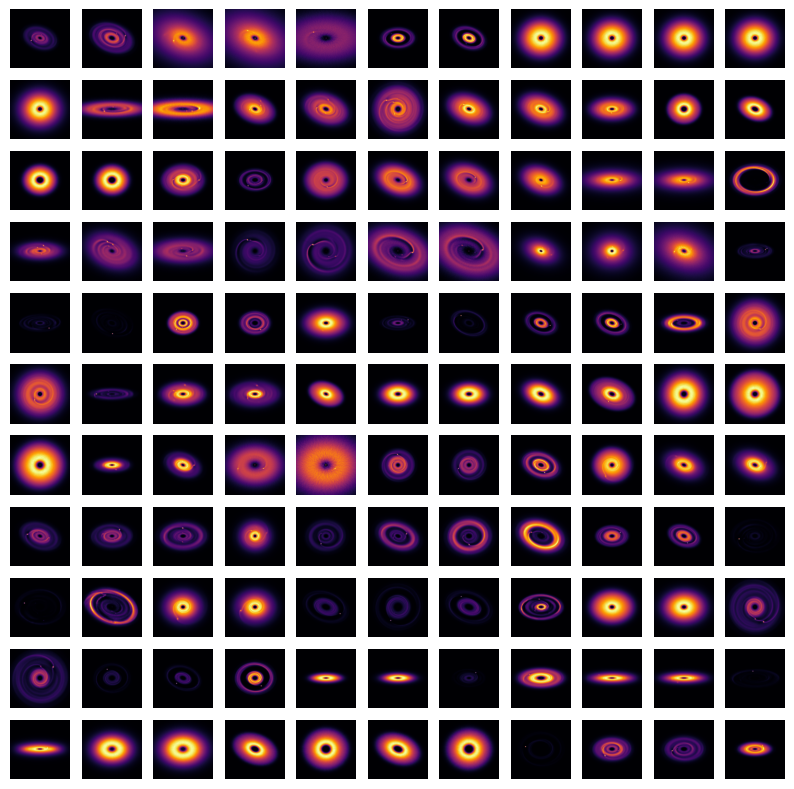

In [ ]:
plt.figure(figsize=(10,10))
for i in range(121):
  plt.subplot(11,11,i+1)
  plt.imshow(processed_images[i], cmap='inferno')
  plt.axis('off')
plt.show()

In [ ]:
features = processed_images.reshape(len(processed_images),-1) #flattening
features.shape

(150, 16384)

In [ ]:
#dimensionality reduction

pca = PCA(n_components=50,random_state=42)
features_reduced = pca.fit_transform(features)

print("Reduced feature shape:", features_reduced.shape)
print("Explained variance:", sum(pca.explained_variance_ratio_)) #preserved structural info

Reduced feature shape: (150, 50)
Explained variance: 0.9993486


In [ ]:
#HDBSCAN CLUSTERING

clusterer = hdbscan.HDBSCAN(min_cluster_size=5)
labels = clusterer.fit_predict(features_reduced)

n_clusters = len(set(labels)) - (1 if -1 in labels else 0) #meaningful clusters
noise = np.sum(labels == -1) #noise
print("Number of clusters:", n_clusters)
print("Number of noise points:", noise)

Number of clusters: 5
Number of noise points: 33


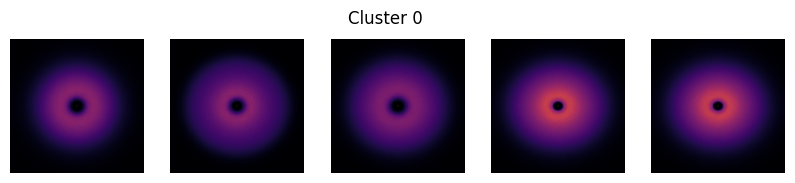

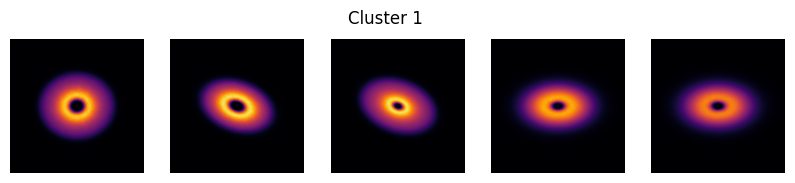

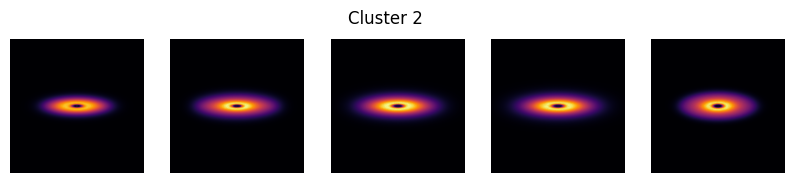

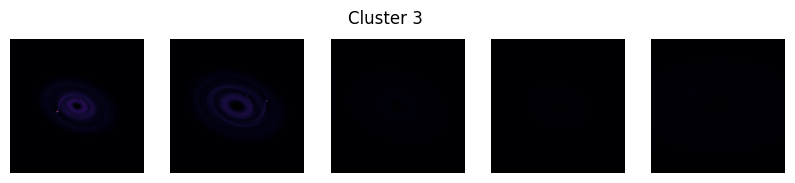

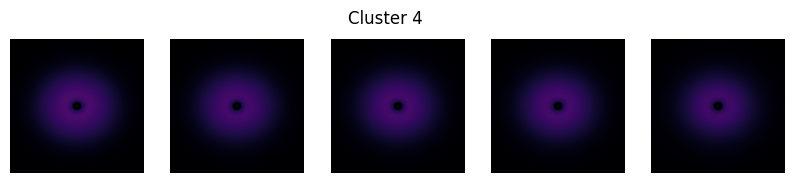

In [ ]:
unique_clusters = np.unique(labels)

for cluster in unique_clusters:
    if cluster == -1:
        continue

    idx = np.where(labels == cluster)[0][:5]

    plt.figure(figsize=(10,2))
    for i, j in enumerate(idx):
        plt.subplot(1,5,i+1)
        plt.imshow(images[j], cmap='inferno')
        plt.axis('off')

    plt.suptitle(f"Cluster {cluster}")
    plt.show()

In [ ]:
#umap visualization

reducer = umap.UMAP(random_state=42)
embedding = reducer.fit_transform(features_reduced)

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


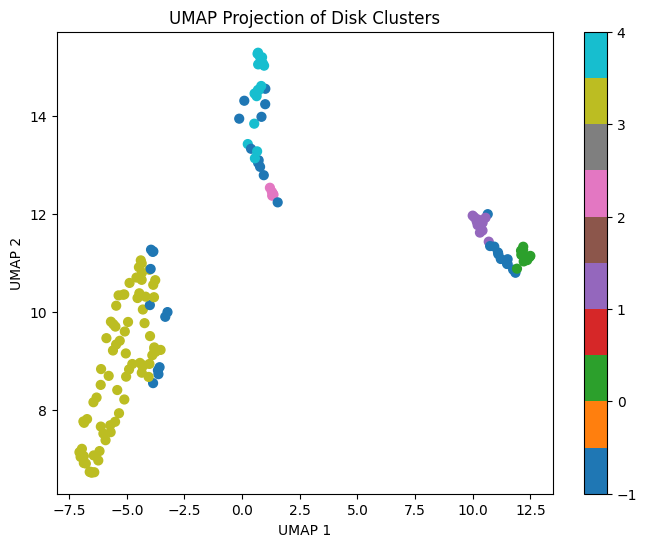

In [ ]:
plt.figure(figsize=(8,6))
scatter = plt.scatter(
    embedding[:,0],
    embedding[:,1],
    c=labels,
    cmap='tab10',
    s=40
)

plt.colorbar(scatter)
plt.title("UMAP Projection of Disk Clusters")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.show()

# Trying to cluster based on physical features
## Phase 1

In [ ]:
#radial profile
def radial_profile(image):
  y,x= np.indices(image.shape)
  center = np.array(image.shape)//2
  r = np.sqrt((x-center[1])**2 + (y-center[0])**2)
  r = r.astype(int)
  tbin = np.bincount(r.ravel(), image.ravel())
  nr = np.bincount(r.ravel())
  radialprofile = tbin/nr
  return radialprofile

In [ ]:
radial_features = np.array([radial_profile(img) for img in processed_images])
print(radial_features.shape)

(150, 91)


In [ ]:
#smoothing

radial_smooth = np.array([gaussian_filter1d(profile,sigma=2) for profile in radial_features])

In [ ]:
#gap detection

def count_gaps(profile):
  peaks, _ = find_peaks(-profile,prominence=0.01) #negating to find dips
  return len(peaks)

gap_counts = np.array([count_gaps(profile) for profile in radial_smooth])

In [ ]:
physics_features = []
for profile in radial_smooth:
  gaps = count_gaps(profile)
  mean_val = np.mean(profile)
  std_val = np.std(profile)
  slope = np.mean(np.gradient(profile))
  physics_features.append([gaps,mean_val,std_val,slope])
physics_features = np.array(physics_features)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
physics_scaled = scaler.fit_transform(physics_features)

In [ ]:
# clustering

clusterer = hdbscan.HDBSCAN(min_cluster_size=12)
labels_phase1 = clusterer.fit_predict(physics_scaled)

n_clusters = len(set(labels_phase1)) - (1 if -1 in labels_phase1 else 0) #meaningful clusters
noise = np.sum(labels_phase1 == -1) #noise
print("Number of clusters:", n_clusters)
print("Number of noise points:", noise)

Number of clusters: 3
Number of noise points: 29


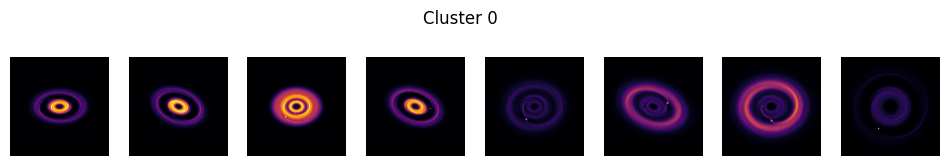

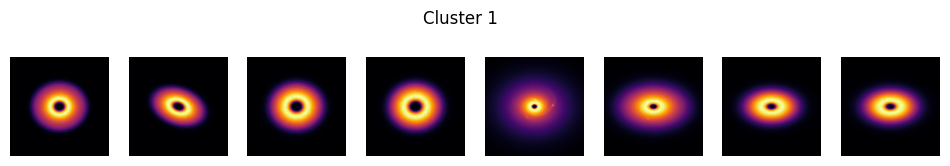

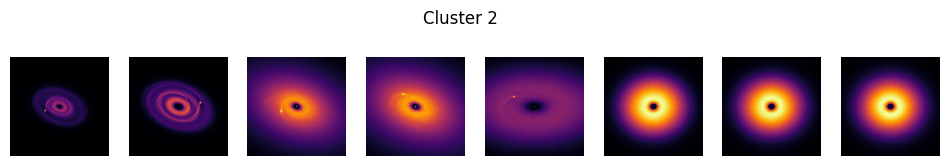

In [ ]:
unique_clusters = np.unique(labels_phase1)

for cluster in unique_clusters:
    if cluster == -1:
        continue

    idx = np.where(labels_phase1 == cluster)[0][:8]

    plt.figure(figsize=(12,2))
    for i, j in enumerate(idx):
        plt.subplot(1,8,i+1)
        plt.imshow(processed_images[j], cmap='inferno')
        plt.axis('off')

    plt.suptitle(f"Cluster {cluster}")
    plt.show()

In [ ]:
from sklearn.metrics import silhouette_score
import numpy as np

# Keep only non-noise points
mask = labels_phase1 != -1
filtered_features = physics_scaled[mask]
filtered_labels = labels_phase1[mask]

In [ ]:
print("Unique clusters:", set(filtered_labels))

Unique clusters: {np.int64(0), np.int64(1), np.int64(2)}


In [ ]:
score = silhouette_score(filtered_features, filtered_labels)

print("Silhouette Score:", score)

Silhouette Score: 0.7778421430755457


# CNN Feature Extraction
## Phase 2

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Convert numpy to torch tensor
tensor_images = torch.tensor(processed_images).unsqueeze(1).float()

dataset = TensorDataset(tensor_images)
loader = DataLoader(dataset, batch_size=16, shuffle=True)

In [ ]:
class Autoencoder(nn.Module):
    def __init__(self):
        super().__init__()

        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, 3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(16, 32, 3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, 3, stride=2, padding=1),
            nn.ReLU()
        )

        # Decoder
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(64, 32, 3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 16, 3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(16, 1, 3, stride=2, padding=1, output_padding=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

In [ ]:
model = Autoencoder().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()

epochs = 30

for epoch in range(epochs):
    total_loss = 0

    for batch in loader:
        imgs = batch[0].to(device)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, imgs)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss/len(loader):.4f}")

Epoch 1, Loss: 0.2031
Epoch 2, Loss: 0.1506
Epoch 3, Loss: 0.0408
Epoch 4, Loss: 0.0101
Epoch 5, Loss: 0.0081
Epoch 6, Loss: 0.0085
Epoch 7, Loss: 0.0082
Epoch 8, Loss: 0.0077
Epoch 9, Loss: 0.0083
Epoch 10, Loss: 0.0081
Epoch 11, Loss: 0.0090
Epoch 12, Loss: 0.0082
Epoch 13, Loss: 0.0078
Epoch 14, Loss: 0.0081
Epoch 15, Loss: 0.0082
Epoch 16, Loss: 0.0080
Epoch 17, Loss: 0.0085
Epoch 18, Loss: 0.0077
Epoch 19, Loss: 0.0077
Epoch 20, Loss: 0.0082
Epoch 21, Loss: 0.0079
Epoch 22, Loss: 0.0078
Epoch 23, Loss: 0.0086
Epoch 24, Loss: 0.0080
Epoch 25, Loss: 0.0079
Epoch 26, Loss: 0.0082
Epoch 27, Loss: 0.0080
Epoch 28, Loss: 0.0082
Epoch 29, Loss: 0.0080
Epoch 30, Loss: 0.0076


In [ ]:
model.eval()

with torch.no_grad():
    latent = model.encoder(tensor_images.to(device))

cnn_features = latent.view(len(processed_images), -1).cpu().numpy()

print("CNN feature shape:", cnn_features.shape)

CNN feature shape: (150, 16384)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler_cnn = StandardScaler()
cnn_scaled = scaler_cnn.fit_transform(cnn_features)

In [ ]:
combined_features = np.concatenate(
    [physics_scaled, cnn_scaled],
    axis=1
)

print("Combined shape:", combined_features.shape)

Combined shape: (150, 16388)


In [ ]:
reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    random_state=42
)

embedding = reducer.fit_transform(combined_features)

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [ ]:
from sklearn.metrics import silhouette_score

best_score = -1
best_labels = None
best_config = None

for mcs in [5,10,12,15]:
    for ms in [None]:

        clusterer = hdbscan.HDBSCAN(
            min_cluster_size=mcs,
            min_samples=ms
        )

        labels = clusterer.fit_predict(embedding)

        mask = labels != -1
        n_clusters = len(set(labels[mask])) - (1 if -1 in labels[mask] else 0)
        print(n_clusters,mcs)

        if len(set(labels[mask])) > 1:
            score = silhouette_score(
                embedding[mask],
                labels[mask]
            )

            if score > best_score:
                best_score = score
                best_labels = labels
                best_config = (mcs, ms)

print("Best silhouette score:", best_score)
print("Best config:", best_config)

9 5
2 10
2 12
2 15
Best silhouette score: 0.61410266
Best config: (5, None)


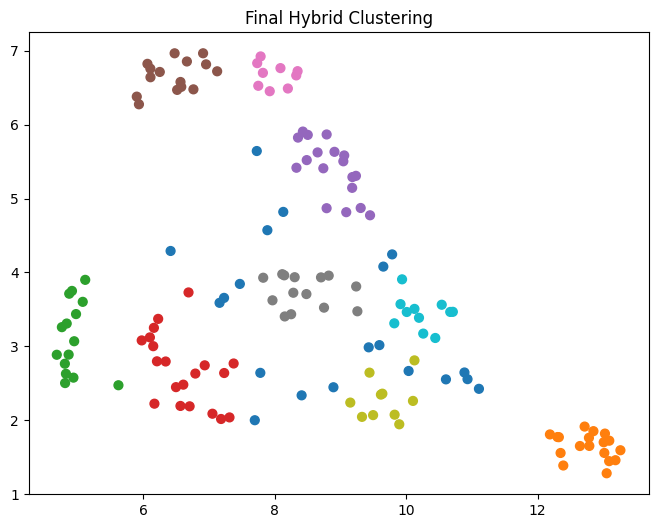

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(
    embedding[:,0],
    embedding[:,1],
    c=best_labels,
    cmap='tab10',
    s=40
)
plt.title("Final Hybrid Clustering")
plt.show()

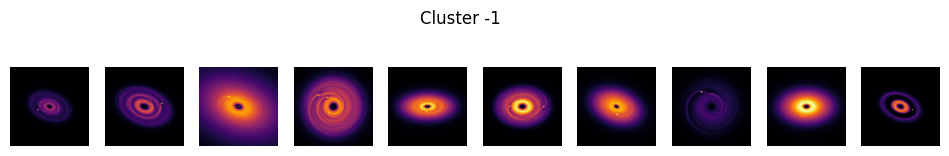

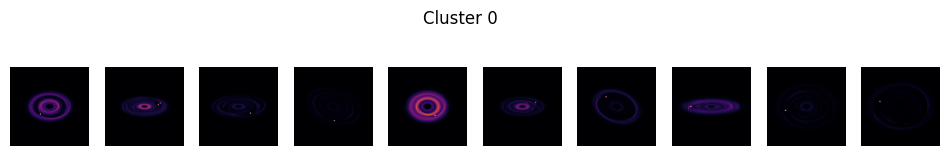

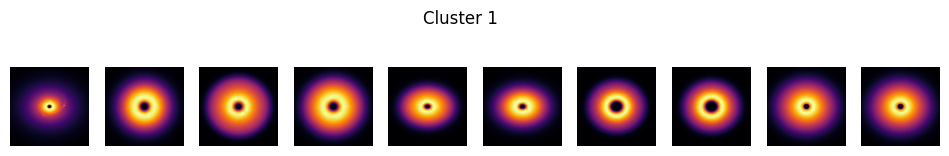

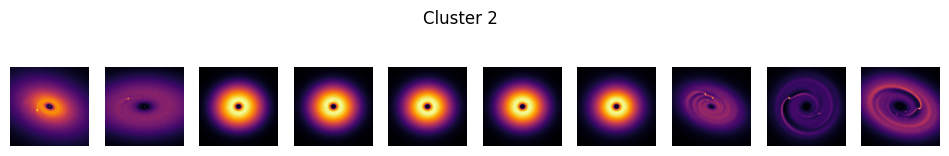

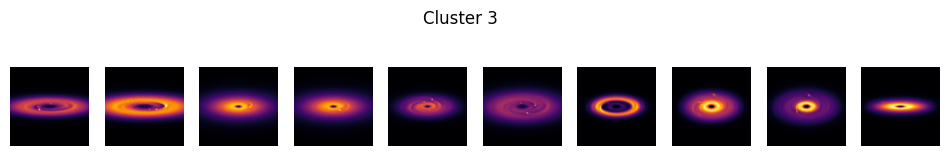

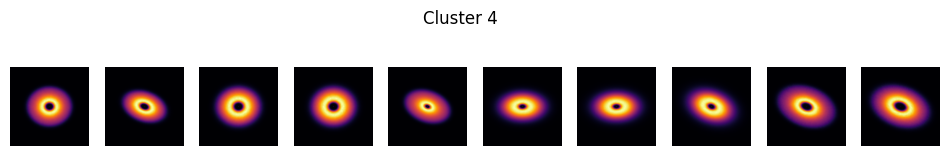

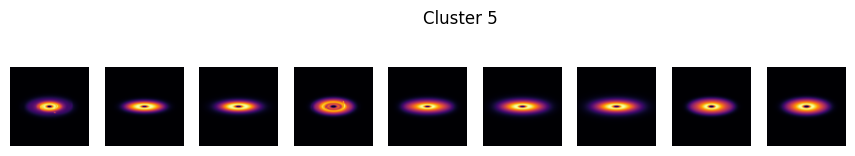

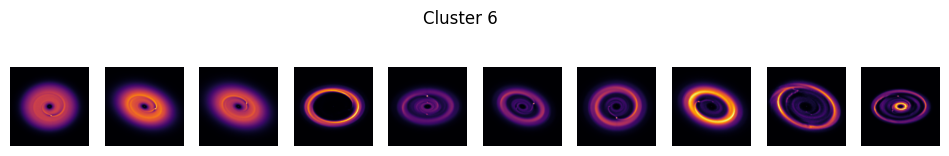

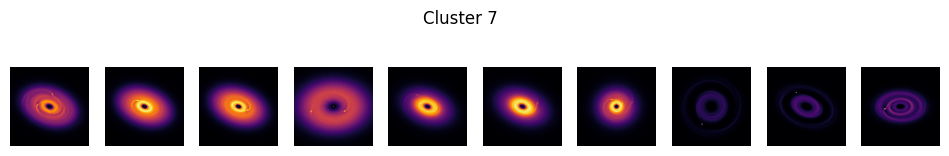

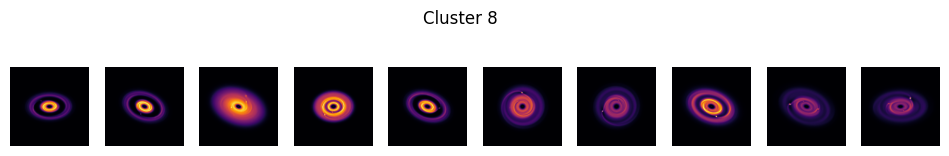

In [ ]:
unique_clusters = np.unique(best_labels)

for cluster in unique_clusters:
    idx = np.where(best_labels == cluster)[0][:10]

    plt.figure(figsize=(12,2))
    for i, j in enumerate(idx):
        plt.subplot(1,10,i+1)
        plt.imshow(processed_images[j], cmap='inferno')
        plt.axis('off')
    plt.suptitle(f"Cluster {cluster}")
    plt.show()